# Study Context

This study uses a historical retail sales dataset from a company operating 45 stores across different regions, with each store consisting of multiple departments. The dataset covers the period from February 5, 2010, to November 1, 2012, and includes information on weekly sales, store characteristics, economic indicators, and promotional activities.

The data is organized into three tables: Stores, which provides information on each store's type and size; Features, which contains external variables such as temperature, fuel prices, the Consumer Price Index (CPI), unemployment rate, promotional markdowns (MarkDown1–5), and holiday indicators; and Sales, which records weekly sales for each department within every store.

Develop an ML model for forecasting weekly department-level sales by combining store characteristics, promotional and holiday information, and historical sales patterns.

# Summary of code

- An initial review of the structure and nature of the available dataframes was conducted, identifying the main variables, data types, and relationships among the information sources.

- Data preprocessing was performed, correcting formatting and data type issues, handling missing values, and generating dummy variables when necessary.

- The different information sources were integrated into a single dataframe, building a structure suitable for statistical analysis and subsequent time series modeling.

- An exploratory data analysis was carried out using tables and visualizations, aimed at identifying temporal patterns, differences across stores and departments, relationships between variables, and potential outliers.

- Outlier treatment was applied to the Weekly_Sales variable using the interquartile range (IQR) method, considering the differences across each store-department combination.

- Temporal variables and interaction terms between markdowns and holiday periods were generated to better represent seasonal and promotional patterns in sales.

- Lag variables and rolling means were constructed to capture the temporal dependence of sales and leverage historical information available for each store-department combination.

- Rolling training and validation windows were defined, maintaining the chronological order of observations to evaluate model performance on unseen periods.

- Hyperparameter optimization was performed using Bayesian Optimization and TimeSeriesSplit, seeking an appropriate XGBoost configuration without breaking the temporal structure of the data.

- Two XGBoost models were developed and compared: a first model based mainly on the original variables, temporal features, and markdown–holiday interactions; and a second model that additionally incorporated lag and rolling mean variables.

- Results showed that including historical information through lags and rolling means considerably improved predictive performance, achieving a validation R² close to 98.34%.



# Key results

1. **Strong predictive performance**

The XGBoost model incorporating lagged sales, rolling averages, store characteristics, and external variables achieved a validation R² of 98.34%, with an average MAE of approximately USD 1,394.52 per department per week and an RMSE of USD 2,848.93. These results indicate that the model is able to explain most of the variation in weekly department-level sales while maintaining relatively low prediction errors.

Compared with the first model, which relied mainly on the original explanatory variables and temporal features, the inclusion of historical sales information improved predictive performance. The validation MAE decreased from approximately USD 1,923.78 to USD 1,394.52, representing a reduction of around 27.5%. Similarly, the validation RMSE decreased from approximately USD 3,297.38 to USD 2,848.93, corresponding to an improvement of around 13.6%.

2. **Historical sales are the main source of predictive information**

The feature importance analysis shows that lagged and rolling sales variables are clearly the most important predictors in the second model. In particular, WS_lag_1 is by far the most important variable, followed by WS_lag_2, WS_roll_4, and WS_lag_4.

This indicates that recent sales behavior contains substantially more information for forecasting future demand than most of the external variables included in the dataset. The result is consistent with the nature of retail demand, where the sales of a specific store and department tend to follow relatively persistent patterns over time.

The importance of these variables also explains the improvement obtained by the second model compared with the first one. Rather than relying mainly on static store characteristics or external conditions, the model can directly use the recent sales history of each store-department combination.

3. **Store and department characteristics remain relevant, but have a secondary role**

Store characteristics continue to contribute to the model, although their importance is considerably lower than that of the lag and rolling variables. Type_B is the most relevant store characteristic in the feature importance analysis, followed by Dept, Type_A, Type_C, and Size.

The descriptive analysis also showed clear differences in average weekly sales between store types. Type A stores presented the highest average sales, followed by Type B and Type C. Therefore, the model still benefits from recognizing structural differences between stores and departments.

However, the results from the second model suggest that these characteristics are mainly useful for distinguishing the baseline behavior of different stores and departments, while recent sales history is more informative for determining the expected sales level in a specific week.

4. **Short-term sales history is substantially more important than long-term history**

The importance of WS_lag_1 and WS_lag_2 is considerably higher than that of WS_lag_12 and WS_lag_52. Similarly, the four-week rolling mean is more important than the twelve- and fifty-two-week windows.

This suggests that recent demand conditions are particularly relevant for predicting the following weeks. Although longer-term information still contributes to the model, much of its predictive value appears to be captured by the more recent observations.

The relatively low importance of WS_lag_52 also indicates that the sales from the same period one year earlier provide less additional information once the model already has access to recent sales history.

5. **Holidays and markdown promotions have limited predictive importance**

Although the exploratory analysis showed differences in average sales between holiday and non-holiday periods, the feature importance results indicate that IsHoliday and the markdown variables contribute very little to the final model compared with the lag and rolling features.

The same applies to the interactions between markdowns and holidays. Their low importance suggests that, once the model knows the recent sales history of each store and department, these variables provide relatively little additional information for predicting weekly sales.

This does not mean that holidays or promotions have no effect on sales. Rather, within this dataset, their independent predictive contribution appears to be limited compared with the information already contained in historical sales.

6. **External economic and environmental variables have a secondary role**

Variables such as unemployment, temperature, and fuel price show very low importance in the second model. Their contribution is considerably smaller than that of the historical sales variables and store-department characteristics.

This suggests that broad external conditions are not the main drivers of short-term sales variation in this dataset. For forecasting purposes, the model obtains considerably more useful information from the previous sales behavior of each store and department.

This result is also consistent with the exploratory correlation analysis, where most of these variables showed relatively weak direct relationships with weekly sales.

7. **The model shows a very small train-validation gap**

The model obtained an R² of 98.21% on the training data and 98.34% on validation. Similarly, the MAE was USD 1,410.43 for training and USD 1,394.52 for validation, while the RMSE was USD 2,891.48 and USD 2,848.93, respectively.

Interestingly, the validation metrics are slightly better than the training metrics. This does not mean that the model is overfitting; in fact, the absence of a performance drop in validation provides no evidence of conventional overfitting in these results. The small differences are likely related to the structure of the rolling-window evaluation and the fact that the validation periods may contain observations that are somewhat easier to predict than some of the training periods.

Overall, the very similar performance across both datasets suggests that the model maintains its predictive capacity when evaluated on observations that were not used to fit each individual training window.

8. **RMSE indicates the presence of some larger prediction errors**

The validation RMSE of USD 2,848.93 is considerably higher than the validation MAE of USD 1,394.52. This difference is important because RMSE penalizes large errors more heavily than MAE.

Therefore, although the average prediction error is around USD 1,395 per department per week, there are some observations where the model makes substantially larger errors. These larger deviations may be associated with atypical sales peaks or periods in which demand behaves differently from its historical pattern.

This is particularly relevant for retail forecasting, since isolated weeks with unusually high sales can have a significant effect on RMSE even when the model performs well across most observations.

9. **The second model is primarily a time-series forecasting model**

Overall, the results show a clear change in the source of predictive information compared with the first model. In the first model, structural variables such as Size, Store Type, and Department had a much more prominent role. After incorporating lagged and rolling sales variables, the model's predictions became dominated by the historical behavior of each store-department combination.

This suggests that the main strength of the second model is not identifying which external factors cause sales to increase or decrease, but rather using previous sales behavior to generate more accurate forecasts of future demand.

Consequently, the model is particularly useful from a forecasting perspective, while the results regarding markdowns, holidays, and external variables should not be interpreted as evidence that these factors have no causal effect on sales.

# Business implications

Based on these results, the main recommendations would be:

- Prioritize store- and department-specific forecasting, since these characteristics have a much stronger relationship with sales than most external variables.
- Use historical sales information when planning inventory and promotions, as lagged and rolling variables significantly improve forecasting accuracy.
- Consider holidays when planning promotional campaigns, since sales tend to be higher during these periods and markdown activity is also more frequent.
- Avoid assuming that markdowns automatically cause higher sales. Their positive association with sales should not be interpreted as a causal effect without a more specific causal analysis.
- Use different strategies according to store type and size, since the observed sales levels differ substantially between store formats.
- Use macroeconomic variables as complementary information, rather than as the main drivers of the forecasting strategy.

# Limitations, Challenges and Potential Improvements

Although the results obtained in this project are positive, there are several aspects that should be considered when interpreting the model and its potential practical application.

1. **Data preparation and construction of the time series**

One of the main challenges of this project was the preparation and integration of the different datasets required to construct a consistent time series. The process involved combining store information, department-level sales, promotional variables, holidays, and economic and environmental variables into a single structure.

In a real-world application, this process could be considerably more complex. It would not be enough to have historical information about these variables. To forecast future sales, information such as store characteristics, economic conditions, weather, and promotional activity would also need to be available or forecasted for the period being predicted. Therefore, the practical implementation of the model would depend not only on the forecasting model itself, but also on the availability and quality of future values for the explanatory variables.

2. **Unrealistically high predictive performance**

Another important consideration is the very high R² obtained by the models, particularly after incorporating lagged and rolling features. Although the results indicate strong predictive performance within this dataset, values above 97% or 98% should be interpreted with caution in a real-world forecasting context.

Sales data observed in real business environments are generally affected by many factors that are difficult to observe or measure, such as unexpected changes in consumer behavior, competitor actions, stock availability, local events, changes in pricing strategies, and other operational factors. Therefore, obtaining such a high R² in a real forecasting problem would be relatively uncommon.

For this reason, the results should be understood primarily as an application and learning exercise in time-series forecasting and machine learning rather than as evidence that the model would necessarily achieve the same performance in a real retail environment.

3. **Recursive forecasting and future lagged variables**

The second model relies heavily on lagged sales and rolling averages, which were among the most useful features for improving predictive performance. However, when forecasting several future periods, these variables can become more difficult to obtain.

For example, when predicting the sales of a future week, the previous week's actual sales may not be available because it has not yet occurred. The model would therefore need to use previous predictions to construct subsequent lagged and rolling features. This creates a recursive forecasting process in which prediction errors can accumulate over time.

Therefore, the high performance obtained during validation should not automatically be interpreted as equivalent to the performance of a long-term recursive forecast.

4. **Potential data quality issues**

The dataset also contains characteristics that would require additional investigation before applying the model to a real business problem. In particular, some markdown variables contain negative values and the sales distribution presents a large number of extreme observations.

Although an outlier treatment was applied to Weekly_Sales, these extreme values may represent either genuine demand peaks or data quality problems. Automatically modifying them can improve model stability, but it can also remove information that may be relevant for forecasting exceptional events.

A real-world implementation would therefore require a more detailed investigation into the origin of these observations before deciding whether they should be removed, transformed, or retained.

5. **Possible improvements**

Several improvements could be considered in future versions of the project:

- Incorporate additional variables that may influence sales, such as prices, inventory levels, store openings or closures, competitor activity, local events, and product availability.
- Develop forecasts for the explanatory variables themselves when their future values are not known.
- Perform a forecast oversample.


#  





### Load libraries

In [1]:
#We begin by loading libraries and suppressings warnings.

import pandas as pd      
import numpy as np       
import matplotlib.pyplot as plt  
import matplotlib.dates as mdates 
import seaborn as sns  
import xgboost as xbg 
from xgboost import XGBRegressor 
from sklearn.model_selection import TimeSeriesSplit 
from skopt import BayesSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import warnings 

warnings.filterwarnings('ignore')

### Data load

In [2]:
#With pandas, we load the dataframes of sales, features and stores. 

Sales_df = pd.read_csv(r'C:\Users\rnanc\OneDrive\Escritorio\Programación\Bases de datos\sales.csv')
Features_df = pd.read_csv(r'C:\Users\rnanc\OneDrive\Escritorio\Programación\Bases de datos\features.csv') 
Stores_df = pd.read_csv(r'C:\Users\rnanc\OneDrive\Escritorio\Programación\Bases de datos\stores.csv') 

In [3]:
#With pandas, we display the first and last 10 rows of the dataframes.
pd.concat([Sales_df.head(10), Sales_df.tail(10)]) 

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False
5,1,1,12/03/2010,21043.39,False
6,1,1,19/03/2010,22136.64,False
7,1,1,26/03/2010,26229.21,False
8,1,1,02/04/2010,57258.43,False
9,1,1,09/04/2010,42960.91,False


In [4]:
pd.concat([Features_df.head(10), Features_df.tail(10)])

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
5,1,12/03/2010,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
6,1,19/03/2010,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False
7,1,26/03/2010,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False
8,1,02/04/2010,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,False
9,1,09/04/2010,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,False


In [5]:
pd.concat([Stores_df.head(10), Stores_df.tail(10)])

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [6]:
#With pandas, we display the information of the dataframes, such as data types and null values.
Sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 13.3 MB


In [7]:
Features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), str(1)
memory usage: 712.0 KB


In [8]:
Stores_df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Store   45 non-null     int64
 1   Type    45 non-null     str  
 2   Size    45 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.2 KB


**Observations:**
- The markdown variables, along with CPI and unemployment in the features DataFrame, require appropriate treatment for missing values. 
- The date fields should be converted into a proper datetime format to ensure precise temporal analysis. 
- The type of store variable in the store Dataframe can be encoded into dummy variables to represent each store category.   

### Data Preprocesing and Descriptive Stadistics

In [9]:
#With pandas, we convert the Dates in the Sales and Features dataframes to datetime format.
Sales_df['Date'] = pd.to_datetime(Sales_df['Date'], format = '%d/%m/%Y') 
Features_df['Date'] = pd.to_datetime(Features_df['Date'], format = '%d/%m/%Y')

In [10]:
#With pandas, we create dummy variables for the type of store in the stores dataframe for subsequent statistical analysis.
dummies = pd.get_dummies(Stores_df['Type'], prefix = 'Type') 
Stores_df = pd.concat([Stores_df, dummies], axis = 1)  

In [11]:
Stores_df['Type_A'] = Stores_df['Type_A'].astype(int) 
Stores_df['Type_B'] = Stores_df['Type_B'].astype(int)
Stores_df['Type_C'] = Stores_df['Type_C'].astype(int)

In [12]:
#With pandas, we display descriptive statistics of the numerical columns of the DataFrames. 
Sales_df.describe() 
Features_df.describe()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,2011-10-31 12:00:00,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
min,1.000000,2010-02-05 00:00:00,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,2010-12-17 00:00:00,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,2011-10-31 12:00:00,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,2012-09-14 00:00:00,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,2013-07-26 00:00:00,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000
std,12.987966,NaN,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259


**Results and observation:**

- The Sales DataFrame comprises 421,570 weekly sales records. 
- The average weekly sales amount to approximately $15,981.26 USD. 
- The presence of negative values, evidenced by the minimum observed, suggests the existence of potential outliers. 
- The pronounced discrepancy between the mean and the maximum weekly sales ($693,099.36 USD) reinforces the likelihood that extreme values are influencing the distribution.

In [13]:
#With pandas, we count the number of rows where weekly sales are negative. 
N_Weekly_Sales = (Sales_df['Weekly_Sales'] < 0).sum() # Cuenta el número de filas donde las ventas semanales son negativas
print(N_Weekly_Sales) 

1285


**Observation:**

-At least 1,285 outliers are associated with negative weekly sales values.

In [14]:
#With pandas, we count the number of unique values in the dept column of the sales dataframe to understand the diversity of departments in the dataset.
Sales_df['Dept'].value_counts() 

Dept
1     6435
2     6435
3     6435
4     6435
7     6435
      ... 
78     235
77     150
65     143
39      16
43      12
Name: count, Length: 81, dtype: int64

**Observation:**

- The DataFrame comprises 43 distinct departments distributed across the stores.

In [15]:
Features_df.describe() 

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,2011-10-31 12:00:00,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
min,1.000000,2010-02-05 00:00:00,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,2010-12-17 00:00:00,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,2011-10-31 12:00:00,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,2012-09-14 00:00:00,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,2013-07-26 00:00:00,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000
std,12.987966,NaN,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259


**Observations and Results**:

- The features dataframe contains 8,190 observations.
- The analysis period spans from February 5, 2010, to July 26, 2013. The median date is October 31, 2011, suggesting a well-balanced temporal distribution of the observations.  
- The average temperature was 59.36°F. Its standard deviation of 18.68°F indicates considerable variability, reflecting climatic differences across regions and seasons.  
- The average fuel price was USD 3.41 per gallon. Its standard deviation of USD 0.43 indicates relatively low variability compared with other variables in the dataset.
- The MarkDown variables contain negative values, which is an unusual characteristic since discounts should not be negative in practice. This suggests the need to investigate the meaning of these records or apply appropriate preprocessing techniques.
- A substantial gap exists between the mean and maximum values of the MarkDown variables, accompanied by large standard deviations. Together with the presence of negative values, this suggests highly skewed distributions and the possible presence of outliers that should be evaluated before model training.
- The Consumer Price Index (CPI) has an average value of 172.46, ranging from 126.06 to 228.98. Its standard deviation of 39.74 reflects substantial variability, likely driven by regional differences and changing economic conditions throughout the study period.  
- The unemployment rate averages 7.83%, ranging from 3.68% to 14.31%. Although its standard deviation is relatively low (1.88%), regional and temporal differences may influence consumer behavior and, consequently, retail sales.

In [16]:
#With pandas, we count the number of rows where any of the MarkDown columns have a negative value. 
N_MarkDowns = (Features_df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']] < 0).sum()
print(N_MarkDowns)

MarkDown1     4
MarkDown2    25
MarkDown3    13
MarkDown4     0
MarkDown5     2
dtype: int64


**Observation:**

-The occurrence of negative values in the MarkDown columns is relatively low.

In [17]:
#With pandas, we fill the missing values in the MarkDown columns of the Features dataframe with 0 and ensure that there are not negative values. 
Features_df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']] = Features_df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].fillna(0).clip(lower=0) 

In [18]:
#With pandas, we count the number of unique values ​​in columns containing non-numeric variables within the dataframes.
Features_df['IsHoliday'].value_counts() 

IsHoliday
False    7605
True      585
Name: count, dtype: int64

**Observation:**

-The distribution of the 'IsHoliday' variable is highly imbalanced. This indicates that holiday periods represent a smallfraction of the dataset, important information regarding the model to be applied.  

In [19]:
#With pandas, we convert the isHoliday variable to the integer type.
Features_df['IsHoliday'] = Features_df['IsHoliday'].astype(int) 

In [20]:
#With pandas, we fill the missing values in the CPI and Unemployment columns of the Features dataframe using linear interpolation to maintain data continuity.
Features_df['CPI'] = Features_df['CPI'].interpolate(method = 'linear')
Features_df['Unemployment'] = Features_df['Unemployment'].interpolate(method = 'linear') 

In [21]:
Stores_df.describe() 

,Store,Size,Type_A,Type_B,Type_C
count,45.000000,45.000000,45.000000,45.000000,45.000000
mean,23.000000,130287.600000,0.488889,0.377778,0.133333
std,13.133926,63825.271991,0.505525,0.490310,0.343776
min,1.000000,34875.000000,0.000000,0.000000,0.000000
25%,12.000000,70713.000000,0.000000,0.000000,0.000000
50%,23.000000,126512.000000,0.000000,0.000000,0.000000
75%,34.000000,202307.000000,1.000000,1.000000,0.000000
max,45.000000,219622.000000,1.000000,1.000000,1.000000


**Results and observations:**

- The average store size is 130,287.6 ft².  
- The standard deviation of store size is 63,825.27 ft², indicating substantial variation in dimensions. This is further confirmed by the wide range between the minimum and maximum store sizes, 34,875 ft² and 219,622 ft², respectively. 
- The median value suggests that approximately half of the stores have an area below 126,512 ft².  
- The diversity in store sizes may provide crucial insights into sales performance, as larger stores typically offer a broader product assortment, greater inventory capacity, and enhanced customer service, among other factors.


In [22]:
Stores_df['Type'].value_counts() 

Type
A    22
B    17
C     6
Name: count, dtype: int64

**Observation:**

- Of the total stores, 22 are classified as Type A, representing the largest format. The next group consists of 17 Type B stores, while the smallest format, Type C, accounts for 6 stores in total.

In [23]:
#With pandas, we merge the Sales, Stores and Features dataframes into a single dataframe for subsequent analysis and modeling. 

merge_df = pd.merge(Sales_df, Stores_df, on = 'Store', how = 'left') 
merge_df = pd.merge(merge_df, Features_df, on = ['Store', 'Date'], how = 'left')

To construct a unified dataset suitable for machine learning applications, three sources of information are integrated into a single DataFrame. Weekly sales records by store and department are first merged with store characteristics, including type and size, using Store as the merge key. The resulting dataset is then enriched with additional variables such as temperature, fuel price, CPI, unemployment rate, and MarkDowns through a join based on Store and Date.

In [24]:
merge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Type          421570 non-null  str           
 6   Size          421570 non-null  int64         
 7   Type_A        421570 non-null  int64         
 8   Type_B        421570 non-null  int64         
 9   Type_C        421570 non-null  int64         
 10  Temperature   421570 non-null  float64       
 11  Fuel_Price    421570 non-null  float64       
 12  MarkDown1     421570 non-null  float64       
 13  MarkDown2     421570 non-null  float64       
 14  MarkDown3     421570 non-null  float64       
 15  MarkDown4     421570 non-nul

In [25]:
#With pandas, we drop the redundant column 'IsHoliday_x' from the new dataframe. 
merge_df = merge_df.drop(columns = ['IsHoliday_x'])

In [26]:
pd.concat([merge_df.head(10), merge_df.tail(10)]) 

,Store,Dept,Date,Weekly_Sales,Type,Size,Type_A,Type_B,Type_C,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,A,151315,1,0,0,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106,0
1,1,1,2010-02-12,46039.49,A,151315,1,0,0,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106,1
2,1,1,2010-02-19,41595.55,A,151315,1,0,0,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106,0
3,1,1,2010-02-26,19403.54,A,151315,1,0,0,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106,0
4,1,1,2010-03-05,21827.90,A,151315,1,0,0,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106,0
5,1,1,2010-03-12,21043.39,A,151315,1,0,0,57.79,2.667,0.00,0.00,0.00,0.00,0.00,211.380643,8.106,0
6,1,1,2010-03-19,22136.64,A,151315,1,0,0,54.58,2.720,0.00,0.00,0.00,0.00,0.00,211.215635,8.106,0
7,1,1,2010-03-26,26229.21,A,151315,1,0,0,51.45,2.732,0.00,0.00,0.00,0.00,0.00,211.018042,8.106,0
8,1,1,2010-04-02,57258.43,A,151315,1,0,0,62.27,2.719,0.00,0.00,0.00,0.00,0.00,210.820450,7.808,0
9,1,1,2010-04-09,42960.91,A,151315,1,0,0,65.86,2.770,0.00,0.00,0.00,0.00,0.00,210.622857,7.808,0


**Observation:**

- The DataFrame generated from the final merge produces the expected results. It preserves the information corresponding to the 421,570 sales recorded in the sales DataFrame, while enriching it with the relevant details for each store and the specific characteristics associated with both store and date.

### EDA

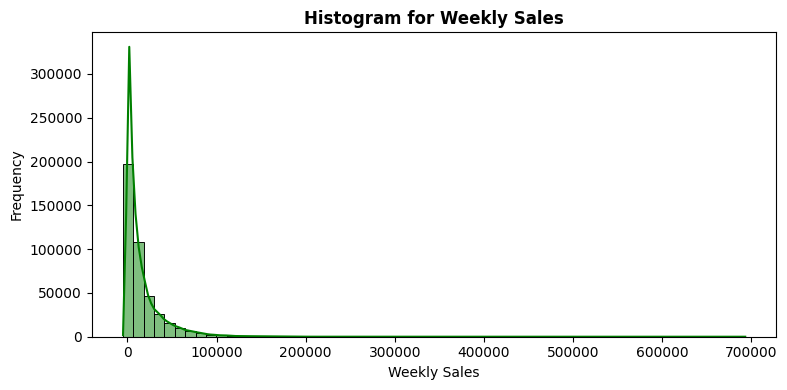

In [27]:
plt.figure(figsize = (8,4))
sns.histplot(merge_df['Weekly_Sales'], bins= 60 ,color = 'g', edgecolor = 'black', kde = True) # Crea un histograma de la columna 'Weekly_Sales' con 50 bins
plt.title('Histogram for Weekly Sales', fontweight='bold') 
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency') 
plt.tight_layout()
plt.show()

**Results and observations:**

- The distribution of weekly sales exhibits a pronounced right skew, with most observations concentrated below $100,000 USD. This asymmetry suggests that the mean may be influenced by a small number of extreme values. 
- The clustering of records within lower ranges indicates that most stores operate within a relatively stable sales level. Sales exceeding $600,000 USD are identified, highlighting the presence of outliers likely linked to special events, promotions, or holiday periods. Consequently, the median provides a more representative measure than the mean for capturing typical sales behavior. 
- The negative sales values are observed, which will require appropriate preprocessing before applying the selected model.

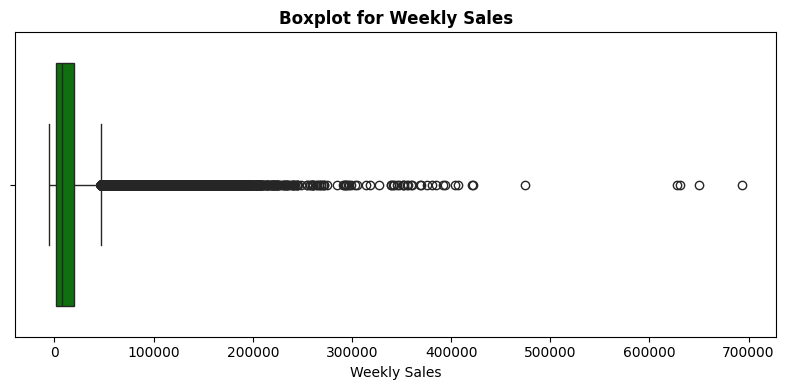

In [28]:
#With pandas, we create a boxplot for the 'Weekly_Sales' column to visualize its distribution, median, quartiles, and possible outliers.
#With sns and matplotlib, we create a boxplot for the 'Weekly_Sales' column to visualize its distribution, median, quartiles, and possible outliers.
plt.figure(figsize = (8,4))
sns.boxplot(x= merge_df['Weekly_Sales'], color = 'g') 
plt.title('Boxplot for Weekly Sales', fontweight='bold')
plt.xlabel('Weekly Sales')
plt.tight_layout()
plt.show()

**Results and observations**

- The boxplot reinforces the previously noted conclusions and highlights the pronounced right skew in the sales distribution.
- The median is located near the lower bound of the IQR box, indicating that most observations correspond to relatively low values compared to the maximum figures observed.
- The IQR is small relative to the overall data range, reflecting moderate dispersion within the central 50% of weekly sales.
- A considerable number of outliers appear above the upper bound, with some exceeding $700,000 USD, far beyond the rest of the observations.
- The extreme values below the lower bound are scarce and of limited magnitude, confirming that outliers are concentrated primarily in the upper end of the distribution.

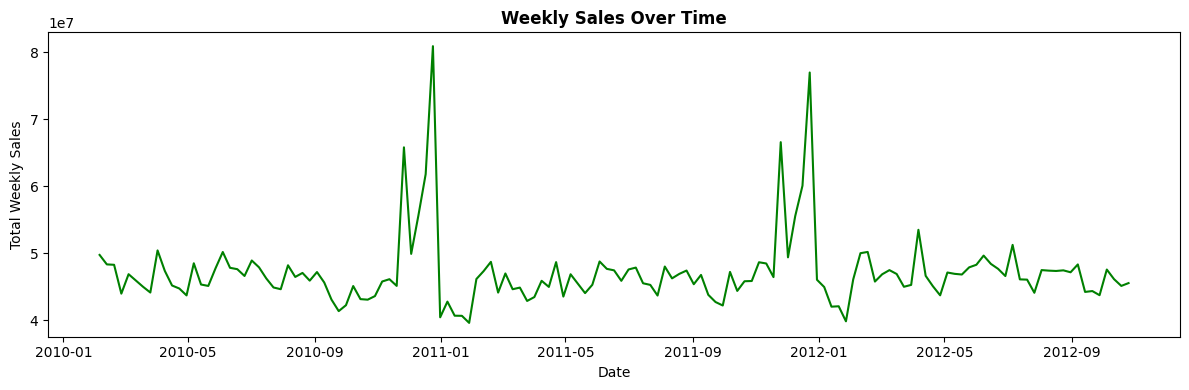

In [29]:
#With pandas, we group the merged dataframe by date and sum the weekly sales for each date, creating a new dataframe with the dates and total weekly sales. 
#With seaborn and mathplotlib, we create a line plot to visualize the comportament of the total weekly sales over time, using previusly created dataframe. 

ds_Weekly_Sales = merge_df.groupby('Date')['Weekly_Sales'].sum().reset_index() 

plt.figure(figsize = (12,4))
sns.lineplot(x= 'Date', y = 'Weekly_Sales', data = ds_Weekly_Sales, color ='g')
plt.title('Weekly Sales Over Time',fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.tight_layout()
plt.show()

**Results and observations**

- The line chart reveals a clear seasonal pattern in weekly sales throughout the analysis period. The sales peaks occur at approximately the same periods each year, reinforcing the presence of a recurring seasonal pattern.
- Pronounced increases in sales are observed between November and January compared to the rest of the year, suggesting an effect associated with periods of high demand such as holidays or promotional campaigns. This justifies the inclusion of variables such as holidays and discounts.
- Outside these seasonal periods, weekly sales remain relatively stable, fluctuating around a similar level throughout the sample.
- No clear long-term upward or downward trend is observed, as overall sales levels remain relatively consistent between 2010 and 2012.

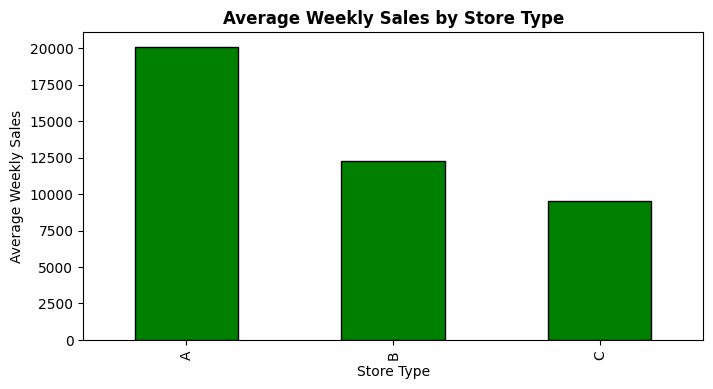

In [30]:
#With pandas, we group the merged dataframe by store type and calculate the mean of weekly sales for each type, creating a bar plot to visualize the average weekly sales by store type.
#With matplotlib, we create a bar plot to visualize the average weekly sales by store type, using the previously calculated means.
plt.figure(figsize = (8,4))
merge_df.groupby('Type')['Weekly_Sales'].mean().plot(kind = 'bar', color = 'g', edgecolor = 'black') 
plt.title('Average Weekly Sales by Store Type', fontweight='bold')
plt.xlabel('Store Type')
plt.ylabel('Average Weekly Sales')
plt.show()

**Results and observations**

- The average sales differ significantly across store formats: Type A stores generate approximately $20,000 USD, Type B stores around $12,000 USD, and Type C stores about $9,500 USD. This highlights a substantial performance gap between the three store types.

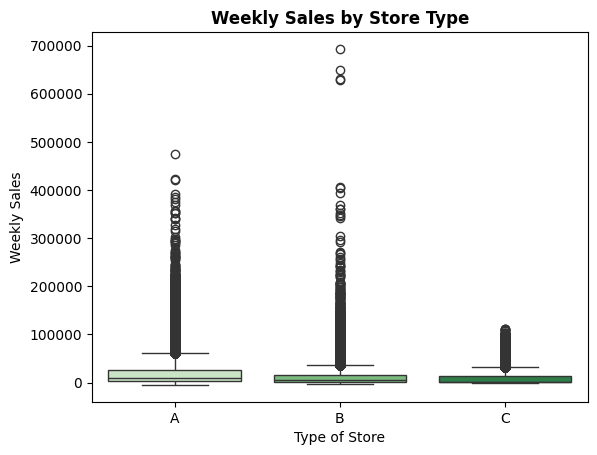

In [31]:
sns.boxplot(data= merge_df, x='Type', y='Weekly_Sales', palette = 'Greens') # Crea un boxplot para comparar la distribución de 'Weekly_Sales' entre los diferentes tipos de tiendas
plt.title('Weekly Sales by Store Type', fontweight='bold')
plt.xlabel('Type of Store')
plt.ylabel('Weekly Sales')
plt.show()


**Results and observations**

- Type A exhibits a wide distribution. Most observations cluster at relatively low levels, yet numerous extreme values exceed $100,000 USD, with some reaching approximately $475,000 USD.
- Type B shows even greater dispersion. Although its average is lower than that of Type A, extreme values appear that reach nearly $700,000 USD.
- Type C presents a much more concentrated distribution, with considerably smaller maximum values, peaking at around $110,000 USD.
- Across all three store types, numerous high-value outliers are present, though they are particularly pronounced in Types A and B.

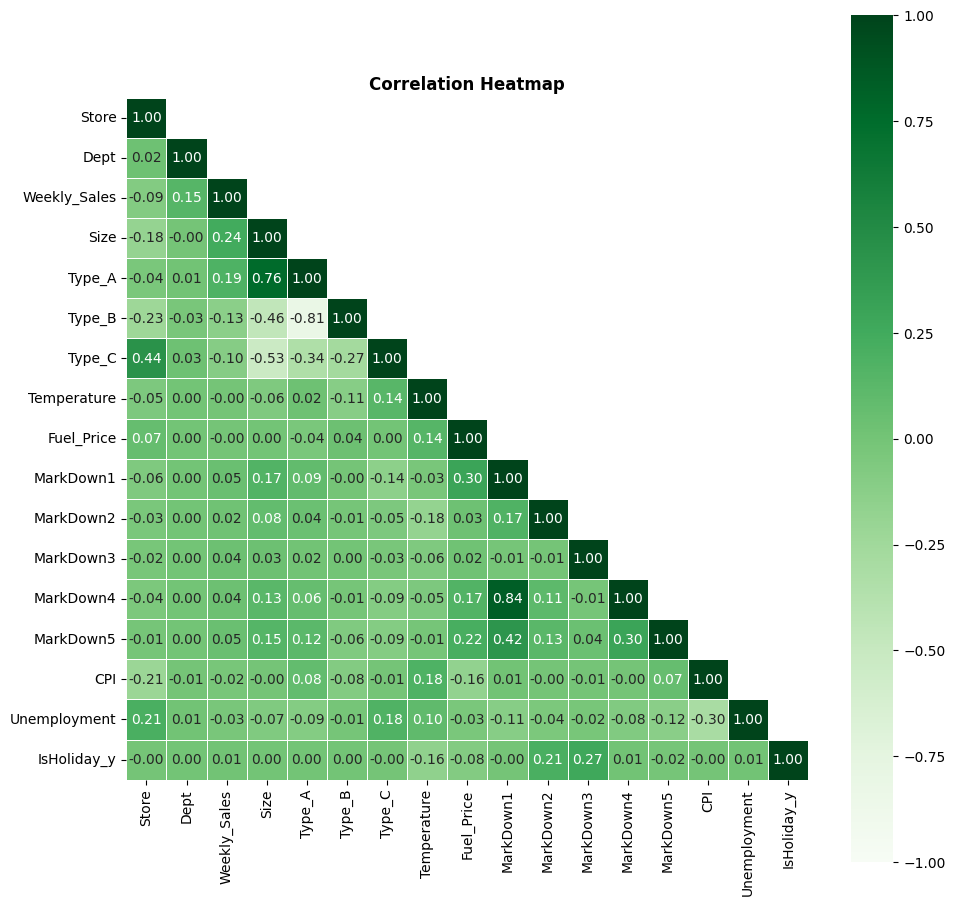

In [32]:
#With pandas, we calculate the correlation matrix of the numerical columns in the merged dataframe. 
#With numpy, we create a mask to hide the upper half of the correlation matrix for better visualization.
#Wtih seaborn and matplotlib, we create a heatmap to visualize the correlation matrix, with annotations and a color scheme to represent the strength of the correlations. 

Corr2 = merge_df.select_dtypes(include=['number']).corr() 
plt.figure(figsize = (11,11))
mask = np.triu(np.ones_like(Corr2, dtype = bool), k = 1) 
sns.heatmap(Corr2 , mask = mask, annot = True, fmt = '.2f', vmin = -1, vmax = 1, square = True, 
            cmap = 'Greens', linewidths = 0.5) 
plt.title('Correlation Heatmap', fontweight='bold')
plt.show()

**Results and observations**

- Weekly sales do not exhibit a strong linear correlation with any of the explanatory variables. The highest positive associations correspond to store size and store type A, with values of 0.24 and 0.19 respectively, while the most relevant negative correlations are observed for store types B and C, at -0.13 and -0.10. Overall, all these relationships are of low magnitude.
- In line with the previous exploratory analysis, variables related to markdowns and holidays, macroeconomic conditions, and climatic factors show weak linear correlations with sales. This suggests that the effect of these variables on sales may depend on non-linear relationships or interactions with other variables.
- The holiday variable shows positive correlations mainly with MarkDown2 and MarkDown3, at 0.21 and 0.27 respectively, while its relationship with the other markdowns is practically negligible. This indicates that certain types of promotions tend to be concentrated during holiday periods.
- Among the promotional variables, relatively high positive correlations are observed, particularly between MarkDown1 and MarkDown4, with a linear correlation of 0.84, as well as moderate associations among other pairs of markdowns. This may suggest that certain types of promotions are often implemented jointly within the same commercial campaign.
- The macroeconomic variables CPI and Unemployment present a moderate negative correlation of -0.30. This result is consistent with the inverse relationship described by economic theory (Phillips curve). However, as with the previously discussed cases, this should be interpreted with caution, since correlation does not imply causation.

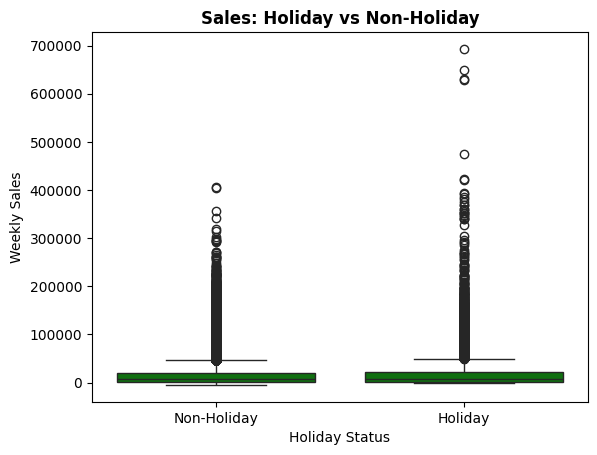

In [33]:
#With seaborn and matplotlib, we create a boxplot to compare the distribution of 'Weekly_Sales' between holidays and non-holidays.
sns.boxplot(data = merge_df, x = 'IsHoliday_y', y= 'Weekly_Sales', color = 'g') 
plt.title('Sales: Holiday vs Non-Holiday', fontweight='bold')
plt.xticks([0,1], ['Non-Holiday', 'Holiday'])
plt.xlabel('Holiday Status')
plt.ylabel('Weekly Sales')
plt.show()

**Results and observations**

- Sales show similar distributions in both holiday and non-holiday weeks, with most observations concentrated below $100,000 USD.
- However, holiday periods display a higher frequency of outliers with substantially larger amounts, reflecting demand peaks linked to celebrations or promotional campaigns.

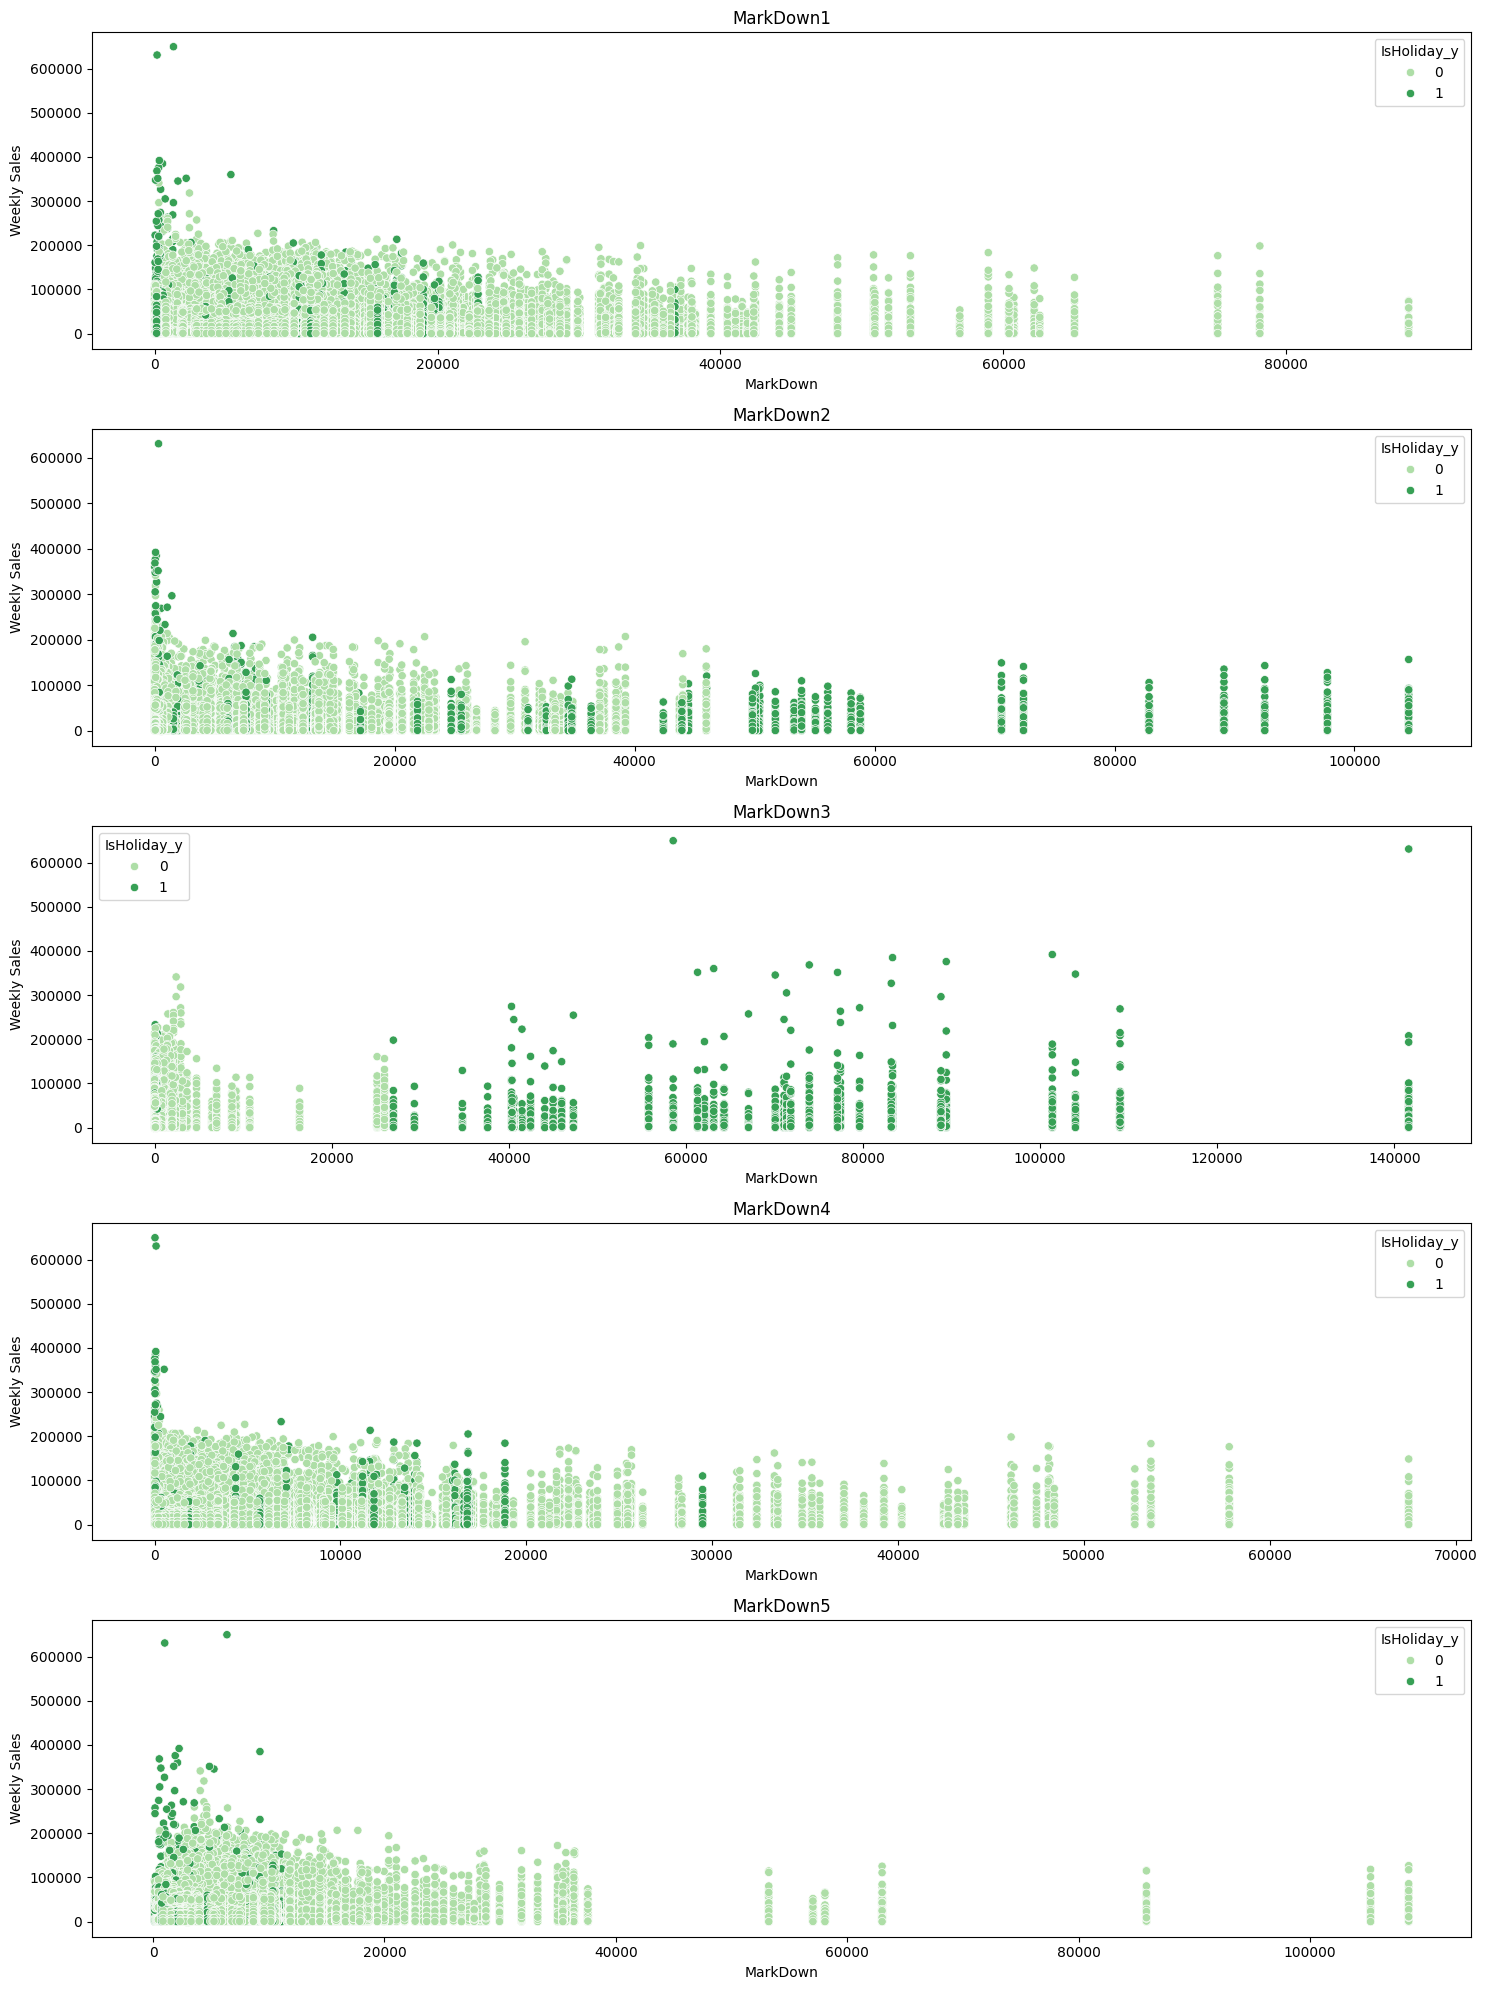

In [34]:
#With seaborn and matplotlib, we create scatter plots to analyze the relationship between each markdown and weekly sales, grouping by holiday status and whether the markdown is active.

fig, axes = plt.subplots(5,1, figsize = (15,20)) 
for i, col in enumerate(['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']): 
    sns.scatterplot(data = merge_df[merge_df[col] > 0], x = col, y = 'Weekly_Sales', hue = 'IsHoliday_y', 
                    ax = axes[i], palette = 'Greens')  
    axes[i].set_title(col)
    axes[i].set_xlabel('MarkDown')
    axes[i].set_ylabel('Weekly Sales') 
plt.tight_layout()
plt.show()

**Results and observations**

- Most observations are concentrated in weekly sales below $100,000 USD and markdowns under $40,000 USD.
- Higher and more frequent discounts are observed during holiday weeks, particularly in MarkDown2 and MarkDown3. While sales generally behave similarly in response to discounts across both holiday and non-holiday periods, MarkDown3 shows deeper reductions associated with substantially higher sales.
- Overall, the wide dispersion of the data confirms that no strong linear relationship exists between sales and markdowns.

In [35]:
#With pandas, we analyze the relationship between each MarkDown and weekly sales by grouping by holiday status and whether the MarkDown is active (greater than 0) or not, and calculate the mean of weekly sales for each group.
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']: 
    resume = merge_df.groupby(['IsHoliday_y', merge_df[col] > 0])['Weekly_Sales'].mean ()
    print({col})
    print(resume)

{'MarkDown1'}
IsHoliday_y  MarkDown1
0            False        15796.577922
             True         16092.805938
1            False        16628.091147
             True         17640.797565
Name: Weekly_Sales, dtype: float64
{'MarkDown2'}
IsHoliday_y  MarkDown2
0            False        15557.188457
             True         16914.272906
1            False        16314.379575
             True         18389.308208
Name: Weekly_Sales, dtype: float64
{'MarkDown3'}
IsHoliday_y  MarkDown3
0            False        15566.329378
             True         16614.400620
1            False        16383.372454
             True         18072.648047
Name: Weekly_Sales, dtype: float64
{'MarkDown4'}
IsHoliday_y  MarkDown4
0            False        15435.531533
             True         16908.113192
1            False        16256.775467
             True         18363.186993
Name: Weekly_Sales, dtype: float64
{'MarkDown5'}
IsHoliday_y  MarkDown5
0            False        15816.567631
            

**Results and observations**

- The average sales are higher during holiday periods and increase when any type of discount is applied.

In [36]:
merge_df = merge_df.drop(columns = ['Type']) 

### Data engineering

In [37]:
#With pandas, we sort the merged dataframe by 'Store', 'Dept', and 'Date' to prepare the data for time-based feature creation, and reset the index to maintain a clean DataFrame structure.
merge_df.sort_values(by =  ['Store', 'Dept', 'Date']).reset_index(drop = True) 
pd.concat([merge_df.head(10), merge_df.tail(10)])

,Store,Dept,Date,Weekly_Sales,Size,Type_A,Type_B,Type_C,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,151315,1,0,0,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106,0
1,1,1,2010-02-12,46039.49,151315,1,0,0,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106,1
2,1,1,2010-02-19,41595.55,151315,1,0,0,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106,0
3,1,1,2010-02-26,19403.54,151315,1,0,0,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106,0
4,1,1,2010-03-05,21827.90,151315,1,0,0,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106,0
5,1,1,2010-03-12,21043.39,151315,1,0,0,57.79,2.667,0.00,0.00,0.00,0.00,0.00,211.380643,8.106,0
6,1,1,2010-03-19,22136.64,151315,1,0,0,54.58,2.720,0.00,0.00,0.00,0.00,0.00,211.215635,8.106,0
7,1,1,2010-03-26,26229.21,151315,1,0,0,51.45,2.732,0.00,0.00,0.00,0.00,0.00,211.018042,8.106,0
8,1,1,2010-04-02,57258.43,151315,1,0,0,62.27,2.719,0.00,0.00,0.00,0.00,0.00,210.820450,7.808,0
9,1,1,2010-04-09,42960.91,151315,1,0,0,65.86,2.770,0.00,0.00,0.00,0.00,0.00,210.622857,7.808,0


This initial step allows us to arrange the observations in the correct sequence. It serves primarily as a quick inspection.

In [38]:
#With pandas, we replace negative values in 'Weekly_Sales' with 0 to avoid issues in analysis and modeling, as sales cannot be negative.
merge_df['Weekly_Sales'] = merge_df['Weekly_Sales'].clip(lower = 0)  

In [39]:
#With pandas, we calculate the first and third quartiles (Q1 and Q3) of 'Weekly_Sales' for each combination of 'Store' and 'Dept', and then compute the interquartile range (IQR) to identify potential outliers.
#We define lower and upper bounds for outlier detection using a multiplier (Mt) of 1.5 times the IQR. Finally, we merge these bounds back into the main dataframe and count the number of detected outliers, printing the results.

Mt = 1.5

limits = merge_df.groupby(['Store', 'Dept'])['Weekly_Sales'].agg(
    Q1= lambda x : x.quantile(0.25),
    Q3= lambda x : x.quantile(0.75)).reset_index()

limits['IQR'] = limits['Q3'] - limits['Q1'] 
limits['lower_b'] = limits['Q1'] - Mt * limits['IQR']
limits['upper_b'] = limits['Q3'] + Mt * limits['IQR']

merge_df = merge_df.merge(limits[['Store','Dept','lower_b','upper_b']], on = ['Store', 'Dept'], how = 'left')

#
outliers = (
    (merge_df['Weekly_Sales'] > merge_df['upper_b']) |
    (merge_df['Weekly_Sales'] < merge_df['lower_b'])
).sum()

print(f"Detected Outliers: {outliers}")
print(f"% of dataset: {outliers / len(merge_df) * 100:.2f}%")

merge_df['Weekly_Sales'] = merge_df['Weekly_Sales'].clip(upper = merge_df['upper_b'], lower = merge_df['lower_b'])

merge_df.drop(columns = ['lower_b', 'upper_b'], inplace = True)


Detected Outliers: 17950
% of dataset: 4.26%


In this step, we identify and handle outliers in the weekly sales variable using a more tailored approach than applying it across the entire dataset. Rather than assuming uniform behavior across all stores and departments, the thresholds are calculated individually for each store-department combination

In [40]:
#With pandas, we create new columns for the year, month, and week from the 'Date' column to capture temporal patterns in weekly sales. 

merge_df['Year'] = merge_df['Date'].dt.year 
merge_df['Month'] = merge_df['Date'].dt.month
merge_df['Week'] = merge_df['Date'].dt.isocalendar().week.astype(int)

#With pandas, we create new columns that represent the interaction between each MarkDown and the holiday status to capture how discounts affect sales during holidays.
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
    merge_df[f'{col}_in_Holiday'] = merge_df[col] * merge_df['IsHoliday_y']

#With pandas, we create new lag columns of sales to capture the temporal dependency in sales, using different time windows (1, 2, 4, 12, and 52 weeks) and grouping by 'Store' and 'Dept' to maintain consistency within each store and department.
lag_windous = [1, 2, 4, 12, 52] 
for window in lag_windous:
    merge_df[f'WS_lag_{window}'] = (
        merge_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(window).fillna(0) 
    )

#With pandas, we create new rolling mean columns of sales to capture short-term and long-term trends in sales, using different time windows (4, 12, and 52 weeks) and grouping by 'Store' and 'Dept' to maintain consistency within each store and department.
rolling_windous = [4, 12, 52] 
for window in rolling_windous:
    merge_df[f'WS_roll_{window}'] = (
        merge_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).rolling(window = window).mean().fillna(0)
        )

To improve the predictive performance of the forecasting model, additional time-based features were engineered. First, the year, month, and week were extracted from the date to capture seasonal patterns in weekly sales. Next, lag features of 1, 2, 4, 12, and 52 weeks were created to incorporate temporal dependencies between consecutive observations. Rolling mean features over 4, 12, and 52 weeks were also computed to represent short-, medium-, and long-term sales trends.

Furthermore, interaction features were created by multiplying each promotional variable by the holiday indicator. These features explicitly model the combined effect of promotions during holiday periods, enabling the model to capture nonlinear relationships and feature interactions more effectively rather than relying solely on successive tree splits.

Finally, two predictive models will be evaluated in this project. The first model will use the original explanatory variables from the dataset, complemented with time-based features (year, month, and week) and interaction variables between promotional discounts and holiday periods. The second model will include all the variables from the first model, together with lag features and rolling mean features. This approach allows for a direct comparison between the predictive power of the original variables and an enriched feature set that incorporates temporal information. Consequently, it will be possible to assess whether modeling the temporal dependence of weekly sales improves forecasting performance and to quantify the additional predictive value provided by these engineered features.

In [41]:
#With pandas, we set up the time series cross-validation using pandas by ordering unique dates, defining the training window and forecast horizon, and initializing a list to store the splits
unique_dates = merge_df['Date'].sort_values().unique()
initial_train_weeks = 52 
forecast_horizon = 52
rolling_windows_splits = []

for i in range(initial_train_weeks, len(unique_dates) - forecast_horizon + 1):
    train_df =  merge_df[ 
        (merge_df['Date'] >= unique_dates[0]) &
        (merge_df['Date'] <= unique_dates[i - 1])
    ].copy()

    val_df = merge_df[ 
        (merge_df['Date'] >= unique_dates[i]) & 
        (merge_df['Date'] <= unique_dates[i + forecast_horizon - 1])
    ].copy()

    rolling_windows_splits.append((train_df, val_df)) 

print(f'\nWindows created: {len(rolling_windows_splits)}')
print(f'\nFirst window until: {rolling_windows_splits[0][0]['Date'].max().date()}')
print(f'\nLast window until: {rolling_windows_splits[-1][0]['Date'].max().date()}')


Windows created: 40

First window until: 2011-01-28

Last window until: 2011-10-28


To test the forecasting models under realistic conditions, we used a time-series cross-validation approach with an expanding training window. The initial training set covers 52 weeks (a full year of historical data), allowing the model to capture annual seasonality before making predictions. We set the forecast horizon to 52 weeks (one calendar year), which corresponds to the target period requested in the challenge, thereby evaluating the model’s ability to perform long-term forecasts.

With each iteration, the validation window moves forward by one week, keeping all past data in the training set. As a result, the training data grows over time, mirroring how forecasting models are updated in real-world workflows as new data becomes available. This setup also prevents data leakage, since each validation set only contains future observations relative to its training set.

In [42]:
#Using pandas, we define the target variable and the explanatory variables established in previous steps.

selected_features1 = [ #Identificators 
    'Store', 'Dept',
    #Information for store
    'Size', 'Type_A', 'Type_B', 'Type_C', 
    #Information for features
    'CPI', 'Unemployment', 'Temperature', 'Fuel_Price', 
    #Holiday 
    'IsHoliday_y', 
    #Markdows
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4','MarkDown5', 
    #Interction between Markdowns and holidays
    'MarkDown1_in_Holiday', 'MarkDown2_in_Holiday', 'MarkDown3_in_Holiday', 'MarkDown4_in_Holiday', 
    'MarkDown5_in_Holiday', 
    #Time features
    'Week', 'Month', 'Year']

target = ['Weekly_Sales']

In [ ]:
## With pandas, we manipulate the merged dataframe by selecting the first 80% of the observations# according to their chronological order, sorting the data by date, 
#and resetting the indices to# create a tuning dataset while preserving the temporal structure of the series. 
#With scikit-learn, we define a TimeSeriesSplit object to perform time series cross-validation, ensuring that each validation fold contains observations that occur after its 
#corresponding training set, thereby preventing data leakage.
#With scikit-optimize, we define a parameter search space for hyperparameter tuning of the XGBoost model, specifying ranges and distributions for each hyperparameter.
#With XGBoost, we initialize a BayesSearchCV object to perform Bayesian optimization for hyperparameter tuning, using the defined parameter space, cross-validation strategy, 
#and scoring metric.

cutoff_date = merge_df['Date'].quantile(0.5)
tuning_df = merge_df[merge_df['Date'] <= cutoff_date].sort_values('Date').reset_index(drop=True)

X_tuning = tuning_df[selected_features1].copy()
y_tuning = tuning_df[target].copy()

print(f"\nData for tuning: {X_tuning.shape[0]} observations (up to {cutoff_date.date()})")

tscv = TimeSeriesSplit(n_splits=5)

param_space = {
    'max_depth':         (3, 8),
    'learning_rate':     (0.01, 0.3, 'log-uniform'),
    'n_estimators':      (100, 500),
    'min_child_weight':  (1, 10),
    'subsample':         (0.6, 1.0),
    'colsample_bytree':  (0.6, 1.0),
    'gamma':             (0, 5),
    'reg_alpha':         (0, 5),
    'reg_lambda':        (0, 5)
}

opt = BayesSearchCV(
    estimator= XGBRegressor(random_state=42, verbosity=0),
    search_spaces=param_space,
    n_iter=40,
    cv=tscv,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Searching for the best hyperparameters using BayesSearchCV...\n")
opt.fit(X_tuning, y_tuning)

print(f"\n The best hyperparameters found:")
for param, value in opt.best_params_.items():
    print(f"   {param}: {value}")
print(f"Best R² in cross-validation: {opt.best_score_:.4f}")

best_params = dict(opt.best_params_)


Datos para tuning: 211285 filas (hasta 2011-06-17)
Searching for the best hiperparameters using BayesSearchCV...

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


**Hyperparameter Tuning via Bayesian Optimization**

To identify the optimal configuration for the XGBoost model, Bayesian optimization was performed using BayesSearchCV from scikit-optimize, combined with TimeSeriesSplit 
cross-validation to preserve the temporal structure of the data and prevent data leakage.The search was conducted over the first 50% of the dataset (chronologically ordered), reserving the remaining 50% for out-of-sample evaluation (one calendar year). The optimization objective was to maximize the R² score across 5 time-series cross-validation folds, iterating over 40 candidate hyperparameter combinations.

The following hyperparameters were tuned, along with their search ranges and theoretical justification:

- max_depth (3, 8): Controls the maximum depth of each decision tree. Shallow trees (low values) produce simpler models with higher bias but lower variance, while deeper trees capture more complex patterns at the risk of overfitting by memorizing training data. The selected range is standard for tabular regression problems.

- learning_rate (0.01, 0.3, log-uniform): Determines the contribution of each new tree to the ensemble. A lower learning rate requires more trees to converge but generally leads to better generalization, while a higher rate accelerates training but increases the risk of overfitting. A log-uniform distribution was used to explore smaller values more thoroughly, as they tend to yield more stable models.

- n_estimators (100, 500): Defines the number of boosting rounds, i.e., the total number of trees in the ensemble. Since each tree corrects the residual errors of its predecessors, a higher number of estimators paired with a low learning rate typically improves performance, though it also increases computational cost.

- min_child_weight (1, 10): Specifies the minimum sum of instance weights (Hessians) required to create a new leaf node. Higher values prevent the model from learning overly specific patterns by requiring a minimum amount of data support for each split, acting as a regularization mechanism that improves generalization.

- subsample (0.6, 1.0): Controls the fraction of training observations randomly sampled to build each tree. Values below 1.0 introduce stochasticity into the training process, reducing variance and helping to prevent overfitting by ensuring no single tree sees the entire dataset.

- colsample_bytree (0.6, 1.0): Defines the fraction of features randomly selected when constructing each tree. This technique increases diversity among trees, reduces dependence on any single predictor, and acts as a form of implicit feature regularization, similar in spirit to the random subspace method used in Random Forests.

- gamma (0, 5): Sets the minimum loss reduction required to make a further partition on a leaf node. A higher gamma value makes the algorithm more conservative by only allowing splits that produce a meaningful reduction in the objective function, effectively pruning unnecessary branches and reducing model complexity.

- reg_alpha (0, 5): Applies L1 regularization (Lasso) on the leaf weights. This penalty encourages sparsity by driving some feature contributions toward zero, resulting in a more parsimonious model that focuses on the most relevant predictors and avoids overfitting to noise.

- reg_lambda (0, 5): Applies L2 regularization (Ridge) on the leaf weights. Unlike L1, this penalty smoothly shrinks all coefficients toward zero without forcing them to be exactly zero, improving model stability, reducing variance, and enhancing generalization, particularly when predictors are correlated.

**Optimal Hyperparameters and Interpretation**

Following 40 iterations of Bayesian search evaluated across 5 time-series cross-validation folds, the optimization process identified the following configuration as optimal,achieving an R² of 0.9520 on the cross-validation set. 

The selected configuration reveals several noteworthy patterns that reflect the nature of the dataset and the complexity of the forecasting task.

- The maximum tree depth of 8, the upper bound of the search space, suggests that the model benefits from capturing highly non-linear interactions among the available features, such as the combined effect of store type, department, markdown promotions, and temporal patterns. This is consistent with the heterogeneous structure of the dataset, which spans 45 stores and up to 81 departments with distinct sales dynamics.

- The learning rate of approximately 0.169, combined with 500 estimators, reflects a moderate learning pace that balances convergence speed and generalization. The ensemble is large enough to capture complex patterns across multiple rolling window training sets while avoiding premature convergence.

- Both subsample and colsample_bytree were set to 1.0, indicating that the optimization process found no benefit in introducing stochastic subsampling at either the observation or feature level. This suggests that the regularization imposed by gamma, min_child_weight, and reg_alpha was sufficient to control model complexity without requiring additional variance reduction through sampling.

- The selected value of min_child_weight (10) reflects a conservative approach to tree growth, as the model requires a relatively high amount of information before creating new splits. In contrast, gamma = 0 indicates that no minimum loss reduction is required beyond an improvement in the objective function for a split to be considered. Therefore, while min_child_weight restricts the creation of overly specific branches, gamma does not impose an additional restriction on tree growth. This combination suggests that the model relies more heavily on the amount of information available at each node to control complexity, while still allowing useful splits to be created even when their individual improvement is relatively small.

- The maximum L1 penalty (reg_alpha = 5) reinforces this conservative approach by strongly penalizing leaf weights associated with non-representative patterns, effectively driving some feature contributions toward zero and producing a more parsimonious model. In parallel, the presence of L2 regularization (reg_lambda = 5) indicates that the optimization process found additional benefit in applying smooth weight shrinkage, complementing the effects of L1 by further stabilizing the model and reducing the risk of overfitting. Taken together, the selected hyperparameters describe a model that prioritizes generalization over memorization, relying on deep but heavily regularized trees to capture the complex and heterogeneous sales dynamics present in the dataset.

In [43]:
#With pandas, we iterate through the rolling windows of training and validation datasets, fitting an XGBoost model with the best hyperparameters found during tuning.
#With scikit-learn, we calculate the mean absolute error (MAE), root mean squared error (RMSE), and R² score for both training and validation sets, storing the results for each rolling window.
#With numpy, we calculate the mean of the performance metrics across all rolling windows to evaluate the overall model performance.

mae_scores = []
rmse_scores = []
r2_scores = []

t_mae_scores = []
t_rmse_scores = []
t_r2_scores = []

for i, (X_train, Y_train) in enumerate(rolling_windows_splits):
    
    X_train = train_df[selected_features1].copy()
    Y_train = train_df[target].copy()

    X_val = val_df[selected_features1].copy()
    Y_val = val_df[target].copy()
    
    model1 = xbg.XGBRegressor(colsample_bytree =  1,
    gamma = 0,
    learning_rate = 0.1694486871362539,
    max_depth = 8,
    min_child_weight = 10,
    n_estimators = 500,
    reg_alpha = 5,
    reg_lambda = 5,
    subsample = 1,
    verbosity = 0)

    model1.fit(X_train, Y_train) 

    predictions = model1.predict(X_val)

    mae = mean_absolute_error(Y_val, predictions)
    rmse = np.sqrt(mean_squared_error(Y_val, predictions))
    r2 = r2_score(Y_val, predictions)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    t_predictions = model1.predict(X_train)

    t_mae = mean_absolute_error(Y_train, t_predictions)
    t_rmse = np.sqrt(mean_squared_error(Y_train, t_predictions))
    t_r2 = r2_score(Y_train, t_predictions)

    t_mae_scores.append(t_mae)
    t_rmse_scores.append(t_rmse)
    t_r2_scores.append(t_r2)

print(f'MAE train: {np.mean(t_mae_scores):.4F} vs MAE val {np.mean(mae_scores):.4F}')
print(f'RMSE train: {np.mean(t_rmse_scores):.4F} vs RMSE val {np.mean(rmse_scores):.4F}')
print(f'R² train: {np.mean(t_r2_scores):.4F} vs R² val {np.mean(r2_scores):.4F}')

MAE train: 1113.1361 vs MAE val 2287.1484
RMSE train: 1845.2672 vs RMSE val 4183.5416
R² train: 0.9927 vs R² val 0.9646


At this stage, empty lists are initialized to store the performance metrics obtained for the training and validation sets across each rolling window. Next, for every partition, the predictor matrix (X) and target variable (Y) are extracted for both the training and validation datasets. An XGBoost model is then trained using the optimal hyperparameters obtained during the Bayesian optimization stage. Once the model has been fitted, predictions are generated for both the validation and training sets, and the MAE, RMSE, and R² metrics are computed for each case. Finally, the metrics obtained across all rolling windows are averaged to evaluate the overall performance of the model and assess its generalization capability.

Regarding the results, the MAE indicates that the model achieves an average absolute prediction error of $1,113.14 USD per department per week on the training set, while this error increases to $2,287.15 USD on the validation set. The difference between both datasets is $1,174.01 USD, which is expected since the model was fitted exclusively on the training data and subsequently evaluated on previously unseen observations.

In terms of R², the model explains approximately 99.27% of the variability in weekly sales for the training set and 96.46% for the validation set. The difference between both values is only 2.81 percentage points, indicating that the model maintains a very similar predictive performance on both seen and unseen data. Consequently, there is no significant evidence of overfitting, as the model preserves a high predictive capability when evaluated on out-of-sample observations.

Regarding the RMSE, the model achieved values of $1,845.27 USD for the training set and $4,183.54 USD for the validation set. Since RMSE places greater emphasis on large prediction errors, these results suggest that although the model provides accurate predictions for most observations, there are some departments or weeks in which the prediction errors are considerably larger than average. This behavior is consistent with the exploratory analysis that revealed periods of atypical demand within the time series. Nevertheless, the difference between the training and validation RMSE aligns with the differences observed in both the MAE and R² metrics, reinforcing the conclusion that the model exhibits good generalization ability and robust predictive performance on previously unseen data.


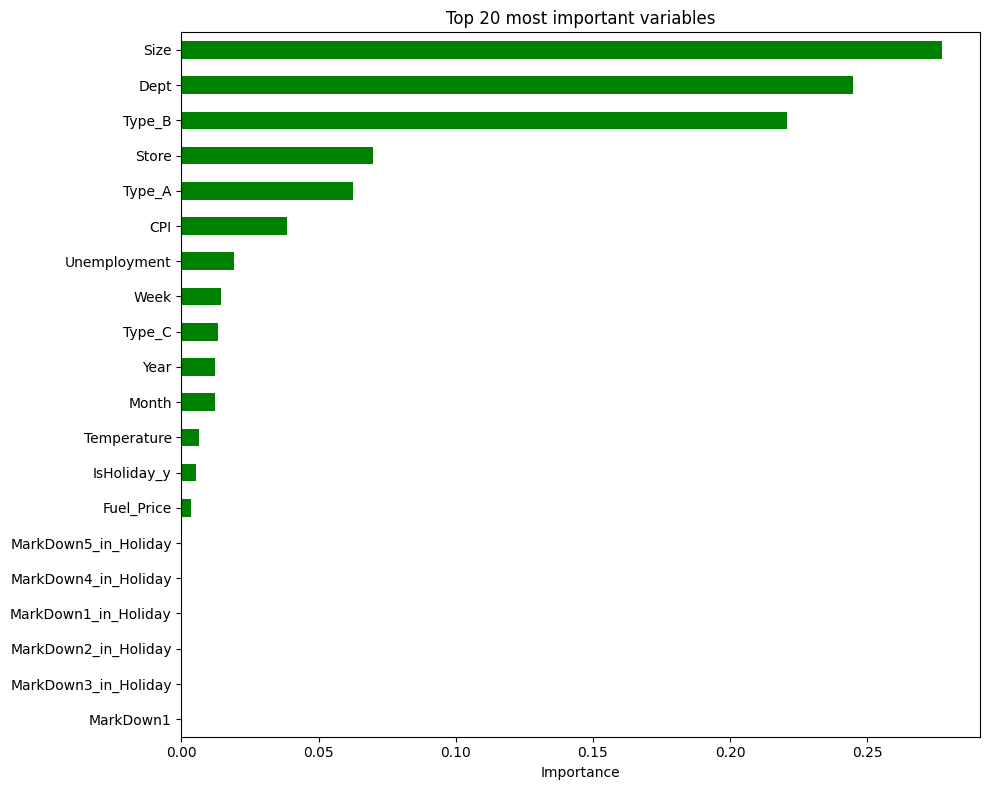

In [44]:
#With pandas, we create a Series object to hold the feature importances from the trained XGBoost model, associating each importance value with its corresponding feature name. 
#We then sort these values in ascending order and select the top 20 most important features for visualization.
#With matplotlib, we create a horizontal bar plot to visualize the top 20 most important features, setting the figure size, color, title, and axis labels for clarity.

importance = pd.Series(
    model1.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(20)

importance.plot(kind='barh', figsize=(10, 8), color= 'g')
plt.title('Top 20 most important variables')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

To conclude the analysis of the first model, we examine the relative importance of the predictor variables estimated by the XGBoost algorithm during training. Feature importance measures how much each variable contributed to reducing the prediction error throughout the construction of the decision trees. Variables with higher importance were either selected more frequently or generated more informative splits, thereby contributing more to the model's predictive performance. The main findings are summarized below.

- Store size (Size) is, by a considerable margin, the most important predictor, accounting for approximately 25% of the total feature importance. This suggests that the physical capacity of a store is one of the primary determinants of weekly sales, as larger stores generally offer a wider product assortment and serve a greater number of customers.

- Store type (Type_B, Type_A, and Type_C) also exhibits a substantial influence, with Type_B ranking as the second most important variable. This indicates that the operational characteristics associated with different store formats have a significant impact on sales performance.

- The identifiers Dept and Store also rank among the most influential variables, particularly Dept. This finding suggests that systematic differences exist across both departments and stores, which the model successfully exploits to improve its predictions. In other words, not all departments or stores exhibit the same sales levels or temporal behavior.

- The macroeconomic variables, CPI and Unemployment, show a moderate level of importance, with CPI contributing more than the unemployment rate. This indicates that economic conditions provide additional explanatory information for weekly sales, although their contribution is considerably smaller than that of the structural characteristics of the stores.

- The temporal variables (Week, Month, and Year) display relatively low importance, with Week being the most relevant among them. This suggests that seasonality exists within the data, although its contribution is less influential than the structural characteristics of the stores.

- The IsHoliday_y variable exhibits low importance, suggesting that holidays alone explain only a small proportion of the variability in weekly sales. Their effect may already be partially captured by other variables, such as the week of the year, store characteristics, or promotional activities. Similarly, the Fuel_Price variable shows limited relevance, indicating that fluctuations in fuel costs do not exert a direct influence on sales dynamics. This outcome is consistent with the fact that its impact is likely embedded within broader macroeconomic indicators, particularly the Consumer Price Index (CPI), which already reflects changes in energy prices and their indirect effects on household consumption.

- The promotion variables (MarkDown1–MarkDown5) and their interactions with holidays contribute extremely little to the model. In practical terms, this implies that promotional discounts, both during regular weeks and holiday periods, do not constitute a determining factor in the variability of sales. Their apparent influence in some cases is better explained by spurious correlations or by their interaction with other model characteristics—such as store type, week of the year, or macroeconomic conditions—rather than by a direct impact on sales.

Overall, the results indicate that the structural characteristics of the stores are the primary drivers of weekly sales, outweighing the influence of external economic conditions, promotional activities, and temporal factors. This finding suggests that differences among stores and departments play a much more important role in determining sales performance than short-term external events. 

In [45]:
#With pandas, we define the target variable and the explanatory variables established in previous steps.

selected_features2 = [ #Identificators 
    'Store', 'Dept',
    #Information for store
    'Size', 'Type_A', 'Type_B', 'Type_C', 
    #Information for features
    'CPI', 'Unemployment', 'Temperature', 'Fuel_Price', 
    #Holiday 
    'IsHoliday_y', 
    #Markdows
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4','MarkDown5', 
    #Interction between Markdowns and holidays
    'MarkDown1_in_Holiday', 'MarkDown2_in_Holiday', 'MarkDown3_in_Holiday', 'MarkDown4_in_Holiday', 
    'MarkDown5_in_Holiday', 
    #Lag and rolling mean features
    'WS_lag_1', 'WS_lag_2', 'WS_lag_4', 'WS_lag_12', 'WS_lag_52', 'WS_roll_4', 'WS_roll_12', 'WS_roll_52',
    #Time features
    'Week', 'Month', 'Year']

target = ['Weekly_Sales']

Compared with the previous model, this one incorporates lag features, rolling means, and temporal variables. The purpose of including these additional features is to provide the model with more information and improve its predictive performance, rather than relying only on the original set of variables provided in the challenge. This allows the model to better capture the temporal dependence and historical patterns present in weekly sales.

In [ ]:
cutoff_date = merge_df['Date'].quantile(0.5)
tuning_df = merge_df[merge_df['Date'] <= cutoff_date].sort_values('Date').reset_index(drop=True)

X_tuning = tuning_df[selected_features2].copy()
y_tuning = tuning_df[target].copy()

print(f"\nDatos para tuning: {X_tuning.shape[0]} filas (hasta {cutoff_date.date()})")

tscv = TimeSeriesSplit(n_splits=5)

param_space = {
    'max_depth':         (3, 8),
    'learning_rate':     (0.01, 0.3, 'log-uniform'),
    'n_estimators':      (100, 500),
    'min_child_weight':  (1, 10),
    'subsample':         (0.6, 1.0),
    'colsample_bytree':  (0.6, 1.0),
    'gamma':             (0, 5),
    'reg_alpha':         (0, 5),
    'reg_lambda':        (0, 5)
}

opt = BayesSearchCV(
    estimator= XGBRegressor(random_state=42, verbosity=0),
    search_spaces=param_space,
    n_iter=40,
    cv=tscv,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Searching for the best hiperparameters using BayesSearchCV...\n")
opt.fit(X_tuning, y_tuning)

print(f"\n The best hiperparameters finded:")
for param, value in opt.best_params_.items():
    print(f"   {param}: {value}")
print(f"The best R² in cross-validation: {opt.best_score_:.4f}")

best_params = dict(opt.best_params_)


Datos para tuning: 211285 filas (hasta 2011-06-17)
Searching for the best hiperparameters using BayesSearchCV...

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


Optimal Hyperparameters and Interpretation

Following 40 iterations of Bayesian optimization evaluated through 5 time-series cross-validation folds, the search procedure identified the following configuration as the best-performing model, achieving an average cross-validation R² of 0.9767. This represents a substantial improvement over the previous specification, suggesting that the inclusion of lagged and rolling mean features provides valuable information for forecasting weekly sales.

The selected hyperparameters also provide insight into the complexity of the forecasting problem and how the model balances predictive accuracy with generalization.

- The maximum tree depth of 8, which corresponds to the upper limit of the search space, indicates that the model benefits from relatively deep trees. This is reasonable because the inclusion of lagged variables and rolling means increases the amount of information available, allowing the model to capture more complex relationships between current and historical sales. However, the relatively high depth also increases the risk of overfitting, making the other regularization parameters particularly important.

- The learning rate of 0.01, combined with 500 estimators, represents a slow learning process with a large number of trees. Each tree makes a relatively small contribution to the final prediction, while the high number of estimators allows the model to gradually improve its predictions. This combination can help capture complex patterns while avoiding the abrupt adjustments that may occur with higher learning rates. However, it also results in a more computationally demanding model.

- Unlike the first model, the optimization selected a subsample value of 0.60 and a colsample_bytree value of 0.60. This means that each tree is trained using approximately 60% of the available observations and 60% of the available features. The introduction of this randomness can reduce the dependence between trees and help control model variance. This is particularly useful in the second model because the inclusion of lagged and rolling variables creates a richer set of predictors with potentially strong relationships between them.

- The selected value of min_child_weight = 1 indicates that the model does not impose a strong restriction on the amount of information required to create a new split. Therefore, the trees are allowed to create relatively specific branches when these provide an improvement in the objective function. In contrast, gamma = 2 introduces a minimum improvement requirement for each new split. This means that although the model can grow relatively freely in terms of the amount of data available at each node, a split must still provide a sufficiently meaningful reduction in the loss function to be accepted. Together, these values allow the model to capture detailed patterns while preventing splits that provide only marginal improvements.

- The regularization strategy also changed compared with the previous model. In this case, L1 regularization was selected with reg_alpha = 2, introducing a penalty on the leaf weights and discouraging the model from relying excessively on very specific patterns. This can contribute to a more controlled model and reduce the influence of noise. On the other hand, reg_lambda = 0 indicates that no additional L2 regularization was selected by the optimization process. Therefore, the model does not apply the smooth weight-shrinkage effect associated with L2 regularization, suggesting that the combination of subsampling, feature sampling, gamma, and L1 regularization was sufficient to control the model's complexity.

In [47]:
mae_scores = []
rmse_scores = [] 
r2_scores = [] 

t_mae_scores = []
t_rmse_scores = []
t_r2_scores = []

for i, (train_df, val_df) in enumerate(rolling_windows_splits):

    X_train = train_df[selected_features2].copy()
    Y_train = train_df[target].copy()

    X_val = val_df[selected_features2].copy()
    Y_val = val_df[target].copy()

    model2 = xbg.XGBRegressor(colsample_bytree = 0.6,
    gamma = 2,
    learning_rate = 0.01,
    max_depth = 8,
    min_child_weight = 1,
    n_estimators = 500,
    reg_alpha = 2,
    reg_lambda = 0,
    subsample = 0.6,
    verbosity=0)

    model2.fit(X_train, Y_train)

#vAL

    predictions = model2.predict(X_val)

    mae = mean_absolute_error(Y_val, predictions)
    rmse = np.sqrt(mean_squared_error(Y_val, predictions))
    r2 = r2_score(Y_val, predictions)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

#TRAIN

    t_predictions = model2.predict(X_train)

    t_mae = mean_absolute_error(Y_train, t_predictions)
    t_rmse = np.sqrt(mean_squared_error(Y_train, t_predictions))
    t_r2 = r2_score(Y_train, t_predictions)

    t_mae_scores.append(t_mae)
    t_rmse_scores.append(t_rmse)
    t_r2_scores.append(t_r2)


print(f'MAE train: {np.mean(t_mae_scores):.4F} vs MAE val {np.mean(mae_scores):.4F}')
print(f'RMSE train: {np.mean(t_rmse_scores):.4F} vs RMSE val {np.mean(rmse_scores):.4F}')
print(f'R² train: {np.mean(t_r2_scores):.4F} vs R² val {np.mean(r2_scores):.4F}')


MAE train: 1410.4336 vs MAE val 1394.5244
RMSE train: 2891.4811 vs RMSE val 2848.9266
R² train: 0.9821 vs R² val 0.9834


At this stage, empty lists are initialized to store the performance metrics obtained for the training and validation sets across each rolling window. Next, for every partition, the predictor matrix (X) and target variable (Y) are extracted for both the training and validation datasets, incorporating a comprehensive set of explanatory variables that includes store identifiers, store characteristics, macroeconomic indicators, holiday flags, markdown promotions and their interactions with holiday periods, lag and rolling mean features derived from the weekly sales series, and calendar-based time features. An XGBoost model is then trained using the optimal hyperparameters obtained during the Bayesian optimization stage. Once the model has been fitted, predictions are generated for both the validation and training sets, and the MAE, RMSE, and R² metrics are computed for each case. Finally, the metrics obtained across all rolling windows are averaged to evaluate the overall performance of the model and assess its generalization capability.

Regarding the results, the MAE indicates that the model achieves an average absolute prediction error of $1,410.43 USD per department per week on the training set and $1,394.52 USD on the validation set. The validation error is therefore approximately $15.91 USD lower than the training error. This difference is very small and indicates that the model maintains a highly similar level of predictive accuracy across both datasets. The slightly lower validation error does not necessarily mean that the model performs better on unseen data, but rather that the validation windows were, on average, slightly easier to predict than the corresponding training observations.

In terms of R², the model explains approximately 98.21% of the variability in weekly sales in the training set and 98.34% in the validation set. The difference between both values is only 0.23 percentage points, with validation showing a slightly higher R². This small difference does not show the typical pattern associated with overfitting, in which training performance is substantially higher than validation performance. Therefore, based on these results, there is no clear evidence of overfitting within the rolling-window evaluation framework. However, the unusually high R² should be interpreted with caution, particularly because the model incorporates lagged and rolling sales variables that provide direct information about previous demand.

Regarding the RMSE, the model achieved values of $2,891.48 USD for the training set and $2,848.93 USD for the validation set. Since RMSE gives greater weight to larger prediction errors, these results indicate that the magnitude of the larger errors is also relatively similar between both datasets. The validation RMSE is approximately $42.55 USD lower than the training RMSE, which represents a relatively small difference compared with the overall magnitude of the metric. This suggests that the validation set does not contain substantially larger prediction errors than the training set. Combined with the MAE and R² results, the RMSE provides further evidence that the model maintains a stable performance when applied to observations that were not used during training.

The inclusion of time-series features, particularly the weekly sales lags at horizons of 1, 2, 4, 12, and 52 weeks, together with rolling mean features calculated over 4, 12, and 52 weeks, appears to provide substantial predictive information to the model. These variables allow XGBoost to incorporate the historical behavior of each store-department combination, capturing short-term, medium-term, and annual patterns in sales. This represents an important improvement over the first model, which relied mainly on the original explanatory variables, calendar information, and markdown-holiday interactions.

The interaction terms between markdown promotions and holiday indicators also allow the model to distinguish promotional activity occurring during regular and holiday periods. However, their presence in the model should not be interpreted as evidence of a direct causal effect of promotions on sales. Their predictive contribution needs to be considered together with the historical sales variables and the other characteristics included in the model.

Overall, the second model presents very high predictive performance and a remarkably small difference between training and validation metrics, with no clear evidence of overfitting under the evaluation procedure applied. The results suggest that incorporating historical sales information through lagged and rolling variables substantially improves the model's ability to forecast weekly sales. Nevertheless, the R² values close to 98% should be interpreted carefully. The strong predictive performance is partly related to the availability of previous sales information, and therefore these results should not automatically be assumed to represent the same level of performance in a real-world forecasting scenario where future explanatory variables or historical information may be more limited.

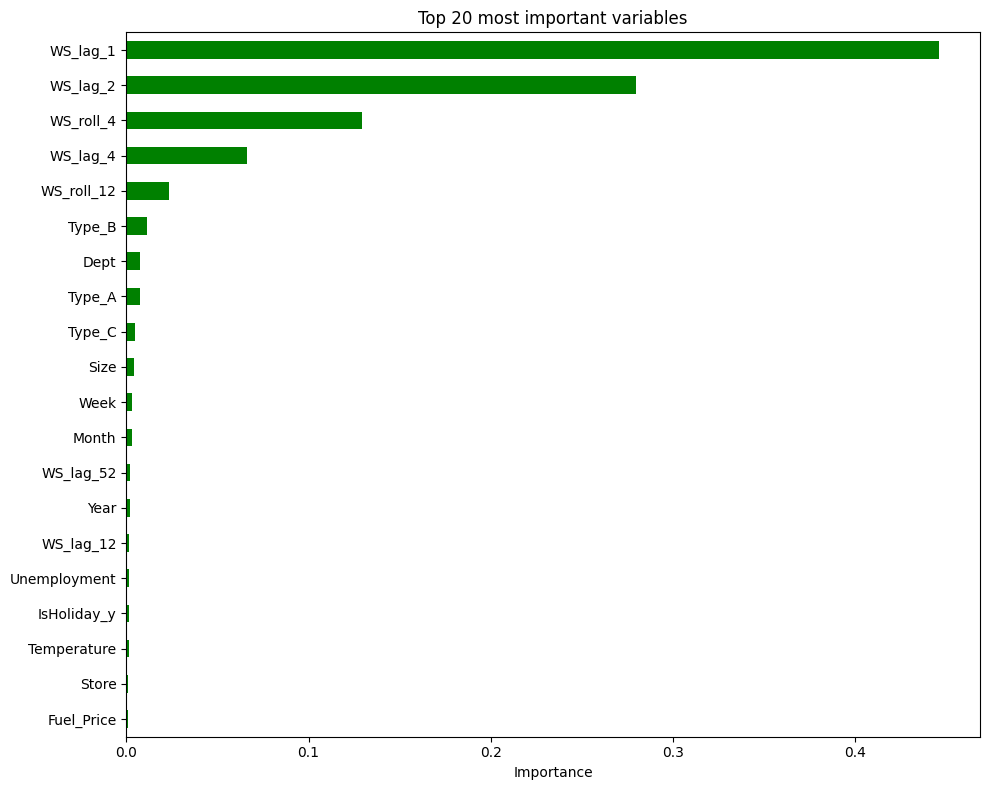

In [48]:
importance = pd.Series(
    model2.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(20)

importance.plot(kind='barh', figsize=(10, 8), color= 'g')
plt.title('Top 20 most important variables')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

To conclude the analysis of the second model, we examine the relative importance of the predictor variables estimated by the XGBoost algorithm during training. Feature importance indicates how relevant each variable was for the construction of the decision trees, based on its contribution to improving the model's objective function through the splits performed during training. Therefore, a higher importance indicates that a variable was more useful for the model when making its predictions, although it should not be interpreted as a direct causal effect or as an exact percentage of predictive power. The main findings are summarized below.

- WS_lag_1 is clearly the most important variable in the model, with an importance of approximately 45%. This indicates that the sales observed one week before are the most useful information for predicting current weekly sales. The result is consistent with the temporal nature of the dataset, where sales from one week to the next tend to maintain a strong relationship within each store-department combination.

- WS_lag_2 is the second most important variable, with an importance close to 28%. Together, WS_lag_1 and WS_lag_2 represent the majority of the feature importance in the model. This reinforces the idea that recent sales history is the main source of predictive information for weekly sales.

- WS_roll_4 and WS_lag_4 are the next most relevant time-series variables, with approximate importances of 13% and 7%, respectively. The rolling average of the previous four weeks provides information about the recent level of demand, while the four-week lag captures sales from approximately one month earlier. Their importance shows that the model does not rely exclusively on the previous week's sales, but also considers the recent evolution of demand.

- WS_roll_12 has a considerably lower importance, of approximately 2–3%. Although the three-month sales trend provides some additional information, its contribution is much smaller than that of the shorter-term variables. This suggests that recent sales behavior is more informative for the model than longer-term averages.

- Store type variables retain a relatively small but noticeable role, with Type_B being the most important of the three, followed by Type_A and Type_C. Their importance is considerably lower than that of the lag and rolling variables. This suggests that store characteristics still help differentiate sales behavior, but their contribution becomes secondary once historical sales information is available.

- Dept also appears among the more relevant non-temporal variables. Its importance indicates that the model continues to identify systematic differences between departments. This is consistent with the fact that different departments can have substantially different sales levels and demand patterns.

- Size presents a low importance compared with the first model. This is an interesting difference, since store size had a much stronger role when the model relied mainly on the original explanatory variables. Once historical sales information is incorporated, part of the information previously provided by store characteristics appears to be captured directly through the lag and rolling variables.

- The explicit time variables Week, Month and Year have very low importance. This suggests that once lagged sales and rolling averages are included, the model requires less information from the calendar variables to identify temporal patterns. In other words, much of the temporal behavior of sales is already represented through the historical sales variables.

- WS_lag_52 also has very low importance, despite representing the same period of the previous year. This suggests that annual historical information contributes relatively little compared with the more recent lags. However, this does not necessarily mean that yearly seasonality is irrelevant; rather, its additional contribution may be limited once the model already has access to recent sales patterns and other temporal variables.

- Macroeconomic variables, holidays and weather have very low importance. Unemployment, IsHoliday_y, Temperature and Fuel_Price are all close to zero in relative importance. This indicates that these variables provide little additional information for the model once the historical sales behavior of each store-department combination is incorporated.
The markdown variables and their interactions with holidays are also largely absent from the most important variables. This reinforces the results obtained previously, where promotional variables showed relatively weak relationships with weekly sales. In this model, their marginal contribution becomes even less relevant after incorporating historical sales information.

Overall, the feature importance results show a clear change compared with the first model. The second model is driven mainly by the historical behavior of weekly sales, particularly the one- and two-week lags, followed by the four-week rolling mean and the four-week lag. Store and department characteristics retain some importance, but their contribution is considerably smaller once the model has access to previous sales.

This result also helps explain the high predictive performance obtained by the second model. Rather than relying mainly on external variables such as promotions, holidays, weather or macroeconomic conditions, the model can use the previous behavior of each store-department combination as a direct source of information. However, this should not be interpreted as evidence that markdowns or holidays have no real effect on sales. Their low feature importance only indicates that they provide limited additional predictive information once recent sales history is already available. It is therefore important to distinguish between the variables that are useful for prediction and the variables that may have a causal effect on demand.

Finally, the importance of the lag variables also highlights a practical consideration for forecasting. The strong dependence on WS_lag_1 and WS_lag_2 means that the model performs its predictions largely by exploiting previously observed sales. This is appropriate for short-term forecasting, but when forecasting several weeks or months into the future, these lagged values may themselves need to be predicted. Consequently, the further the forecast extends into the future, the greater the potential accumulation of prediction errors, which should be considered when interpreting the final forecast.

# Notes on Support and Sources

- For improving the writing and translation of this work, **ChatGPT** and **Copilot** were used.  
- For code creation and optimization, support was provided by **Claude** and **ChatGPT**.  
- The dataset was obtained from **Kaggle**, available at the following link:  
  [Retail Dataset - Kaggle](https://www.kaggle.com/datasets/manjeetsingh/retaildataset/data)
